In [35]:
import sys
sys.path.insert(0, '..')

In [36]:
# Basic imports
import jax.numpy as np
import jax.random as jr
import jax.scipy as jsp
import jax
import numpy

jax.config.update("jax_enable_x64", True)


# Optimisation imports
import zodiax as zdx
import optax
import optimistix as optx

# dLux imports
import dLux as dl
import dLux.utils as dlu

# Visualisation imports
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import matplotlib
import chainconsumer as cc


%matplotlib inline
plt.rcParams['image.cmap'] = 'inferno'
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = 'lower'
plt.rcParams['figure.dpi'] = 72
plt.rcParams["font.size"] = 24

from detectors import *
from apertures import *
from models import *
from fisher import *
from stats import posterior
from fitting import *
from plotting import *
from spectra import *

import jax.tree_util as jtu
import interpax as ipx

def set_array(pytree):
    dtype = np.float64 if jax.config.x64_enabled else np.float32
    floats, other = eqx.partition(pytree, eqx.is_inexact_array_like)
    floats = jtu.tree_map(lambda x: np.array(x, dtype=dtype), floats)
    return eqx.combine(floats, other)

In [37]:
wid = 40
oversample = 4

nwavels = 20
npoly=3

n_modes = 6

optics = NICMOSCoronagraph(512, wid, oversample, n_modes=n_modes)

detector = NICMOSDetector(oversample, wid)

spectrum_basis = np.ones((nwavels, npoly))


# ddir = '../data/NICMOS-LAPL-DD2/LAPL_DATA_DD2/comtemp_flats-DD2/'
ddir = '../data/NICMOS-LAPL-DD1/archive.stsci.edu/missions/hlsp/laplace/dd1/LAPL/NICMOS-LAPL-DD1/LAPL_DATA/contemp_flats/repaired/'


vects = np.load("../data/iterative_spectrum_basis_F160W.npy")[:,:npoly]

assert vects.shape == (nwavels, npoly)


spectrum_basis = vects/np.sqrt(np.mean(vects**2, axis=0))

exposures_single = [

    exposure_from_file(ddir + 'n4qs09akq_clc_calf.fits', SinglePointFit(spectrum_basis, "F160W"), crop=wid),
    exposure_from_file(ddir + 'n4qs10asq_clc_calf.fits', SinglePointFit(spectrum_basis, "F160W"), crop=wid),

    # exposure_from_file(ddir + 'n918a3veq_m_clc_calf.fits', SinglePointFit(spectrum_basis, "F160W"), crop=wid),
]


191.9587 5.4
Version 4.1.1
191.9587 5.4
Version 4.1.1


/Users/haydengreer/PhD/hst/coron/notebooks/../models.py:177: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  return Exposure(filename, name, filter, data, err_with_poisson, bad_with_poisson, fit, mjd, exptime, wcs, pam)
/Users/haydengreer/PhD/hst/coron/notebooks/../models.py:177: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  return Exposure(filename, name, filter, data, err_with_poisson, bad_with_poisson, fit, mjd, exptime, wcs, pam)


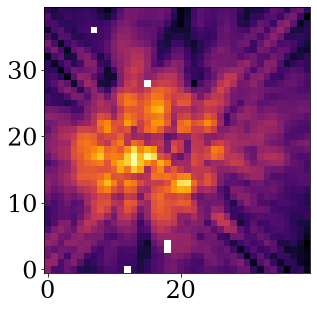

In [38]:
plt.imshow(exposures_single[0].data**0.125)

In [39]:
exposures_single[0].target

'HR8799'

In [40]:
params = {
    "spectrum": {},
    "primary_opd": {},
    "primary_tilt": {},
    "cold_mask_opd": {},
    "cold_mask_tilt": {},
    "cold_mask_shift": {},
    "cold_mask_rot": {},
    "cold_mask_shear": {},
    "cold_mask_scale": {},

    "bias": {},
    "occulter_radius": 0.76,
    "fnumber": 45.3,
}


for idx, exp in enumerate(exposures_single):
    params["spectrum"][exp.fit.get_key(exp, "spectrum")] = (np.zeros(npoly)).at[0].set((np.nansum(exp.data)/nwavels)*6)

    params["primary_tilt"][exp.fit.get_key(exp, "primary_tilt")] = np.array([0.00, 0.])
    params["cold_mask_tilt"][exp.fit.get_key(exp, "cold_mask_tilt")] = np.array([-0.2, -0.15])

    params["primary_opd"][exp.fit.get_key(exp, "primary_opd")] = np.zeros((n_modes, n_modes))
    params["cold_mask_opd"][exp.fit.get_key(exp, "cold_mask_opd")] = np.array([-100.])

    params["cold_mask_shift"][exp.fit.get_key(exp, "cold_mask_shift")] = np.asarray([-13.,-7.])
    params["cold_mask_rot"][exp.fit.get_key(exp, "cold_mask_rot")] = 0.
    params["cold_mask_scale"][exp.fit.get_key(exp, "cold_mask_scale")] = np.asarray([1.,1.])
    params["cold_mask_shear"][exp.fit.get_key(exp, "cold_mask_shear")] = np.asarray([0.,0.])

    params["bias"][exp.fit.get_key(exp, "bias")] = 0.
    


    # params["quadrature"][exp.fit.get_key(exp, "quadrature")] = np.array(0.)


model_single = set_array(NICMOSModel(exposures_single, params, optics, detector))
#model_binary = set_array(NICMOSModel(exposures_binary, params, optics, detector))


params = ModelParams(params)

120.08343017727731
217.42904428386422


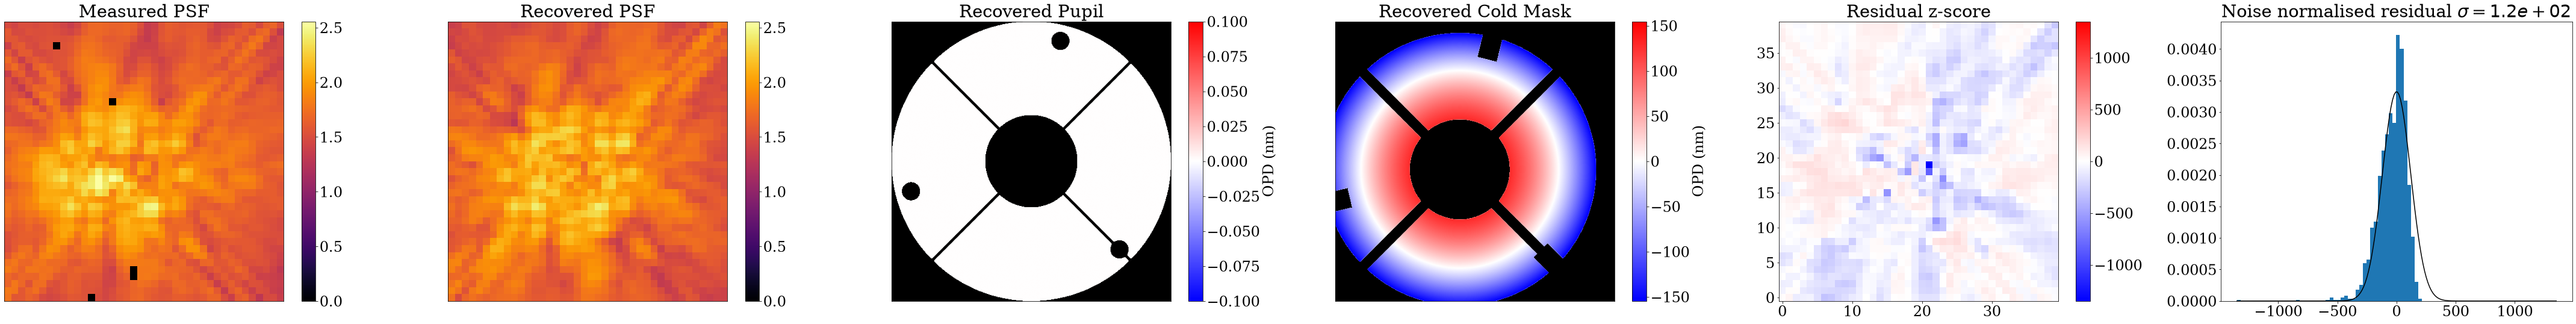

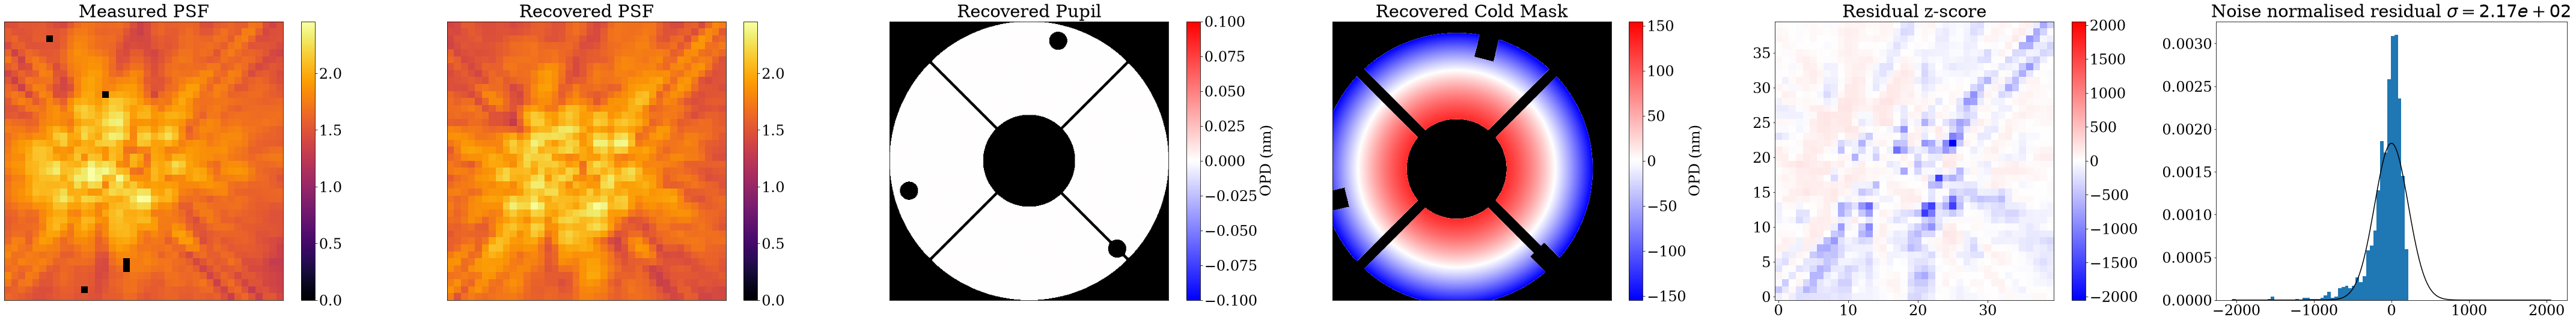

In [41]:
plot_comparison(model_single, params, exposures_single)

In [42]:
def sgd(lr, delay, momentum=0.5):
    return optax.sgd(zdx.optimisation.delay(lr, delay), momentum=momentum)

def adam(lr, delay):
    return optax.adam(zdx.optimisation.delay(lr, delay))


g = 5e-2

things = {
    "spectrum": sgd(g*3., 20),
    # "cold_mask_shift": sgd(g*3, 100),
    
    "bias": sgd(g*4, 30),
    "primary_opd": sgd(g*1., 50),
    # "primary_opd": adam(0.1, 10),

    "cold_mask_opd": sgd(g*1, 10),

    "primary_tilt": sgd(g*3., 40),
    "cold_mask_tilt": sgd(g*5, 0),
    #"jitter": opt(g*1, 120),


    # "cold_mask_shear": sgd(g*2, 200),
    # "cold_mask_rot": sgd(g*10, 200),
    # "cold_mask_scale": sgd(g*20, 200),

    # "quadrature": sgd(g*20, 400)

    "occulter_radius": sgd(g*0.5, 50),
    "fnumber": sgd(g*5, 220),
}

things_start = {
    "positions": sgd(g*5, 0),
}

groups = list(things.keys())

In [43]:
# orig_params = params.params
# opt_params = set_array({k:orig_params[k] for k in orig_params if k in things_start})

In [44]:
# losses, params_history = optimise_new(opt_params, model_single, exposures_single, things_start, 10)

In [45]:
# plot_comparison(model_single, ModelParams(params_history[-1]), exposures_single)

In [46]:
orig_params = params.params #| params_history[-1]
opt_params = set_array({k:orig_params[k] for k in orig_params if k in things})

In [47]:
losses, params_history = optimise_new(opt_params, model_single, exposures_single, things, 100, nbatches=15)

  0%|          | 0/100 [00:00<?, ?it/s]

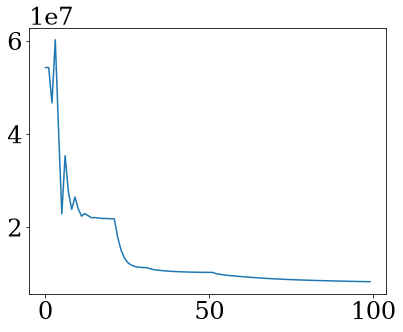

In [48]:
plt.plot(losses[:])

In [49]:
losses[-1]

Array(8332016.25698886, dtype=float64)

8
70.62555004494746
67.98647407860167


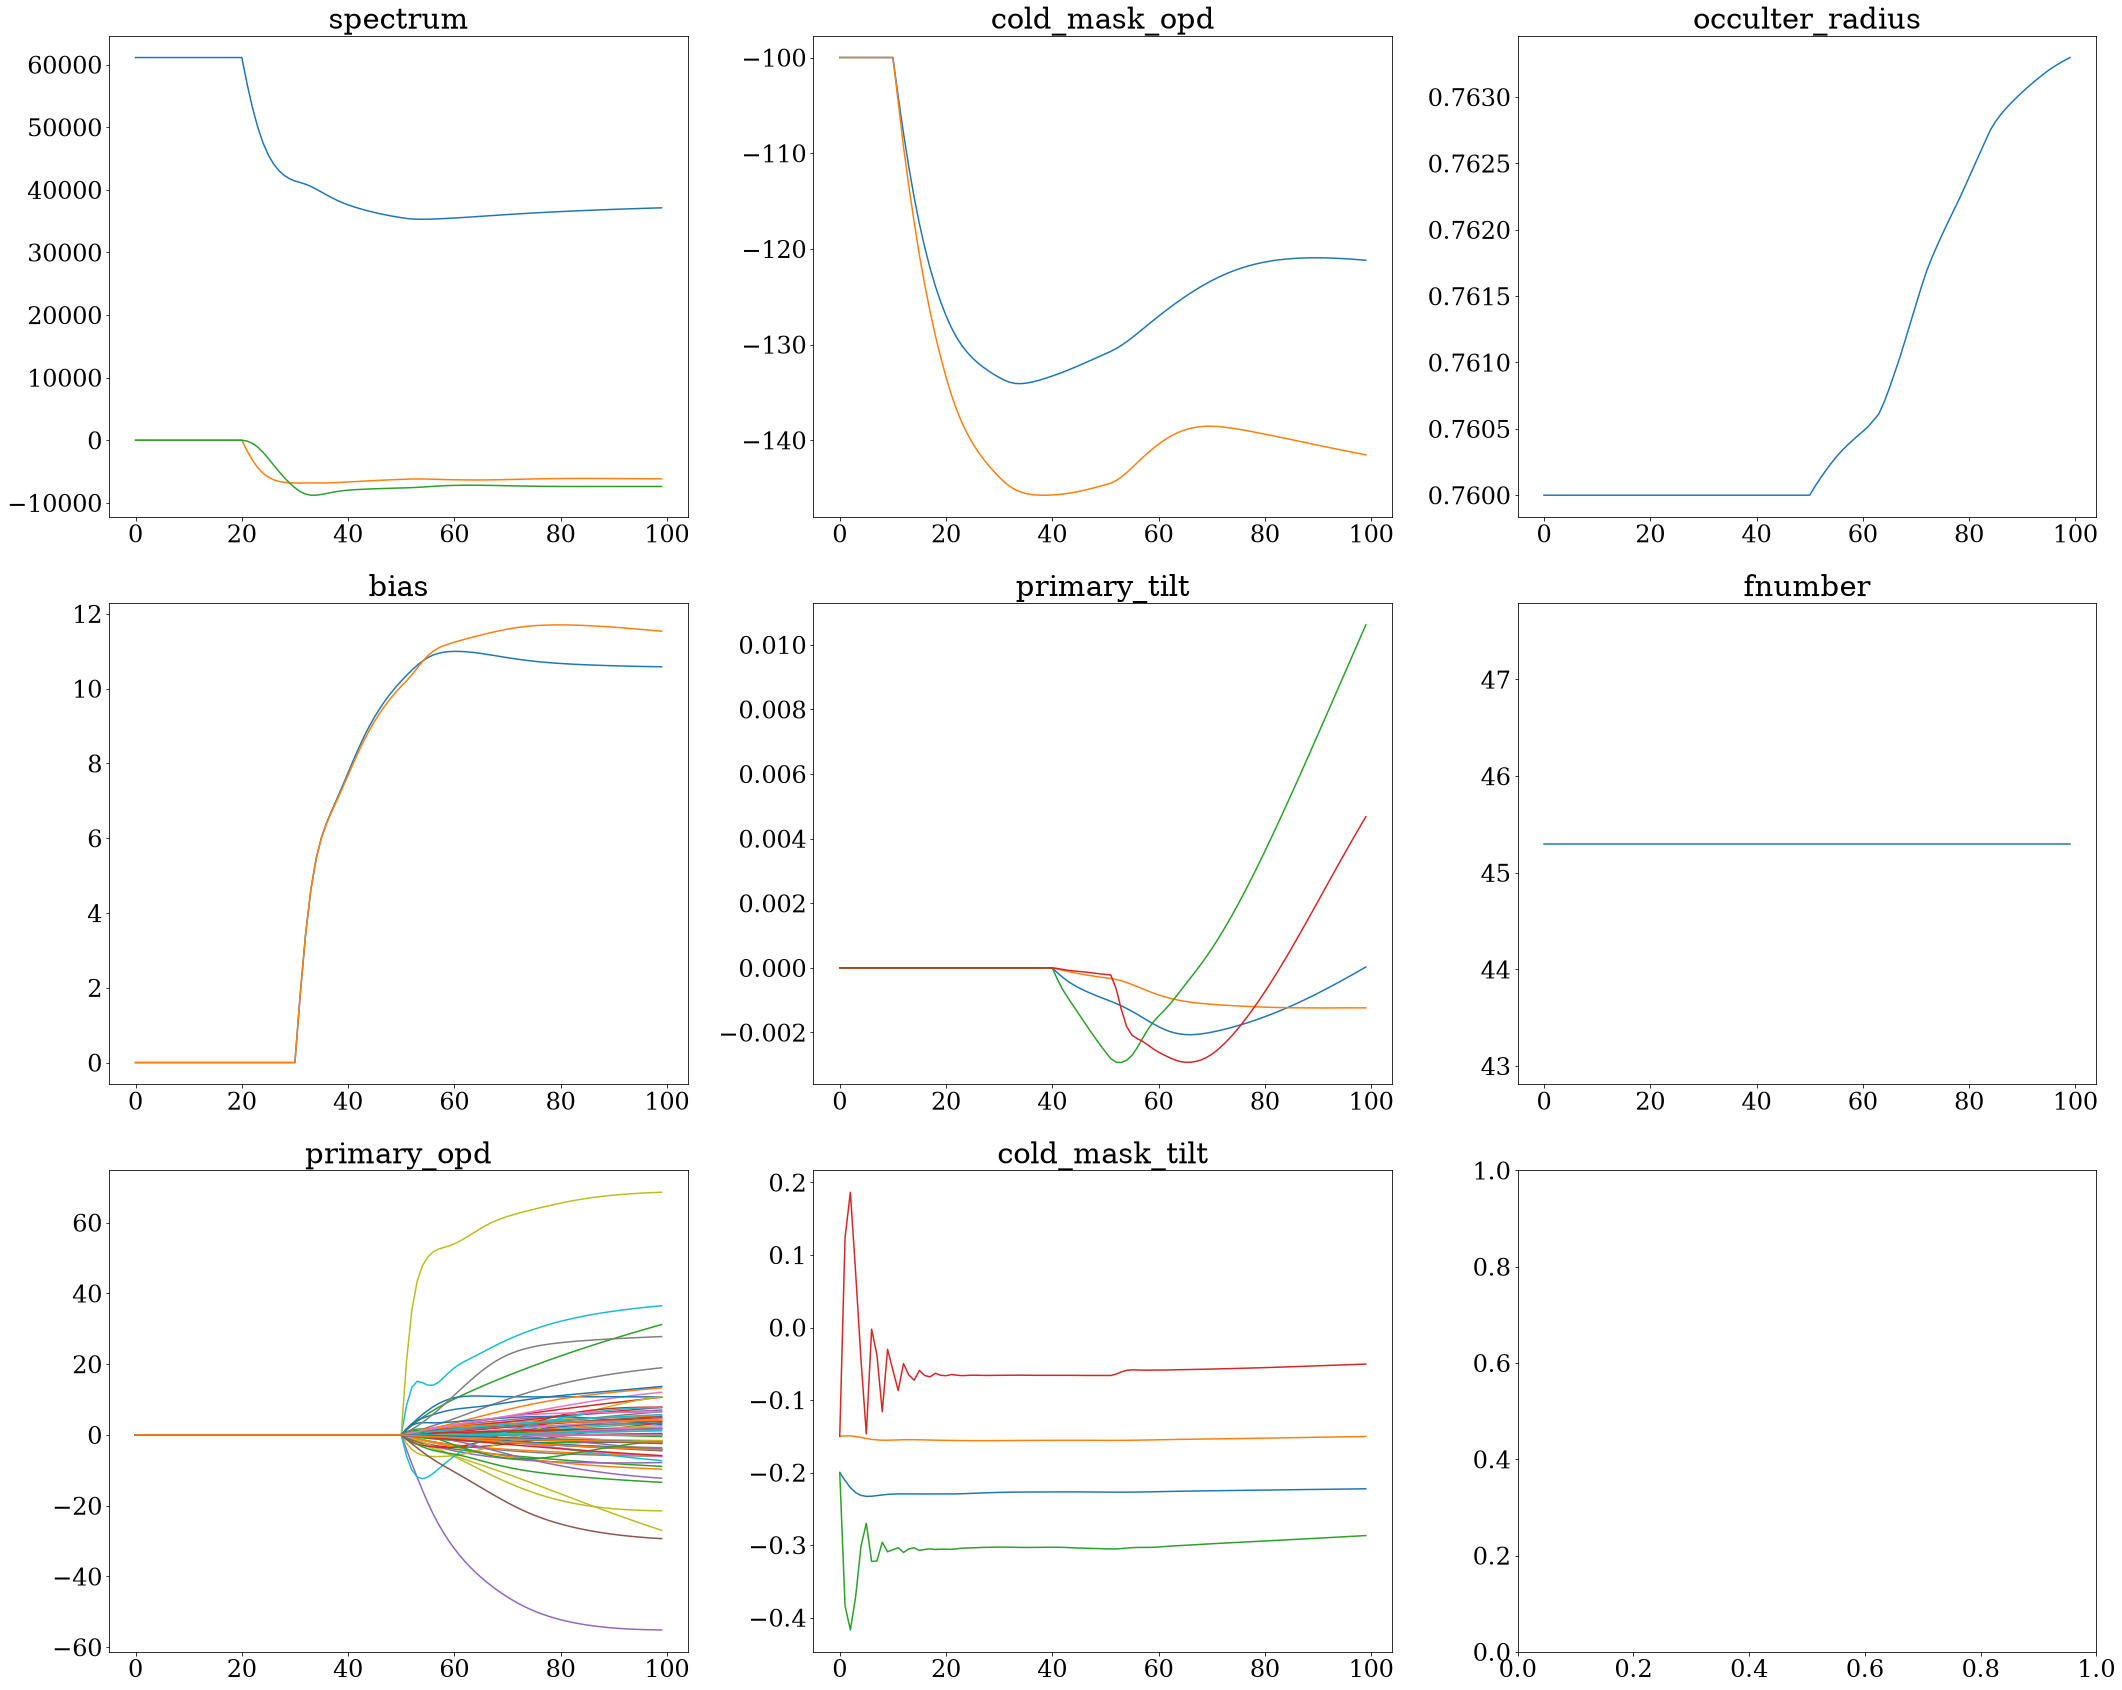

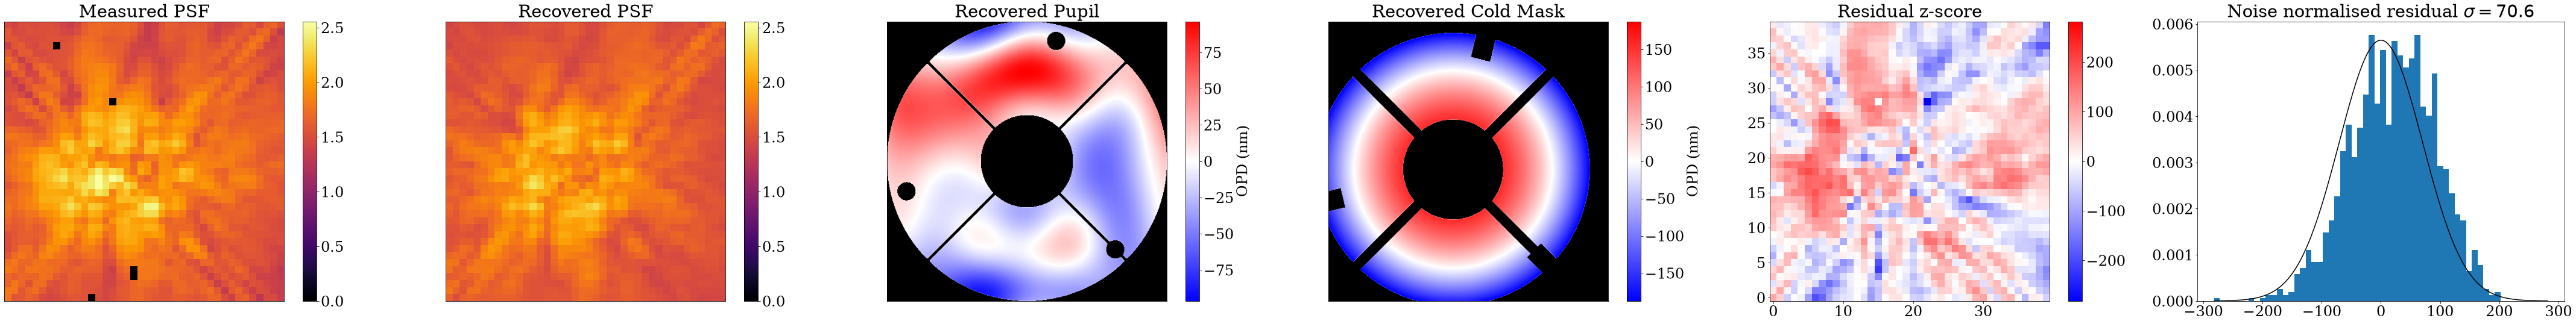

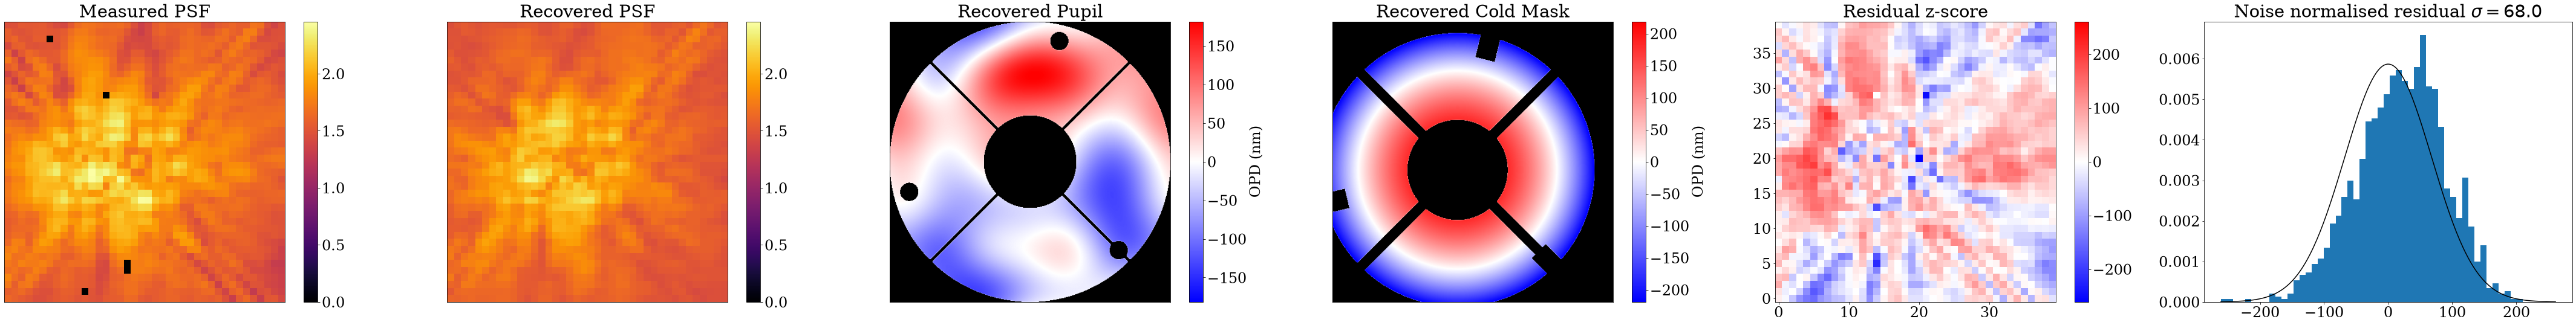

In [50]:
plot_params(params_history, groups, xw = 3)
plot_comparison(model_single, ModelParams(params_history[-1]), exposures_single, quadrature=False)

In [51]:
params_history[-1]

{'bias': {'n4qs09akq': Array(10.58257057, dtype=float64),
  'n4qs10asq': Array(11.5339713, dtype=float64)},
 'cold_mask_opd': {'n4qs09akq': Array([-121.19486361], dtype=float64),
  'n4qs10asq': Array([-141.52611168], dtype=float64)},
 'cold_mask_tilt': {'n4qs09akq': Array([-0.22237771, -0.15028084], dtype=float64),
  'n4qs10asq': Array([-0.28688725, -0.05045217], dtype=float64)},
 'fnumber': Array(45.3, dtype=float64),
 'occulter_radius': Array(0.76329783, dtype=float64),
 'primary_opd': {'n4qs09akq': Array([[  0.        ,   3.9391833 ,  -8.89616811,  10.63364751,
            7.02614659,  -4.00367736],
         [ 12.0444381 ,  -6.07164836, -26.96523254,   3.46919108,
            0.40390468,  -6.0181324 ],
         [ 31.1767429 ,   3.39756791,  -7.83921424,   3.8024435 ,
           -2.5387058 ,   3.30620513],
         [-21.4709662 ,  -7.27424638,   4.63320421,   5.32789757,
           -1.87225691,   7.77859812],
         [ -4.26491811,  -4.49874854,  -6.08736265,  -4.23185325,
         